In [1]:
from profiling_and_attack import mlp_eshard, information, cnn, cnn_ASCAD, mlp

from sklearn.preprocessing import StandardScaler
from utils import *
from tensorflow.keras import Model
from tensorflow.keras.utils import to_categorical
from sklearn.decomposition import PCA
import sys
from matplotlib import pyplot as plt

2025-05-13 14:22:04.439860: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-13 14:22:04.463554: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-13 14:22:04.463593: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-13 14:22:04.464811: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-13 14:22:04.470075: I tensorflow/core/platform/cpu_feature_guar

In [2]:
import tensorflow as tf

def train_linear_probe(x_train, y_train, epochs=5):
    """
    Defines and trains a linear probe with a dense layer on top of extracted features.
    
    Args:
        x_train (np.array or tf.Tensor): Training features.
        y_train (np.array or tf.Tensor): Training labels.
        
    Returns:
        tf.keras.Model: Trained linear probe model.
    """
    # Define the linear probe model (a simple dense layer on the input features)
    num_classes = len(set(y_train))  # Infer number of classes from labels
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=x_train.shape[1:]),  # Input shape based on feature size
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    # Compile the model
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    # Train the linear probe
    model.fit(x_train, y_train, epochs=epochs, batch_size=400)

    return model
def hw(input):

    result = np.zeros_like(input)
    for i in range(8):
        result += (input >> i) & 0x1
    return result

In [ ]:
dataset_id = 'ches_ctf'
traces_dim = 15000

n_prof= 30000
import gc

lm = "HW"
target_byte = 2
path = "./datasets"
dataset = load_dataset(dataset_id, path, target_byte, traces_dim, leakage_model=lm, n_prof=n_prof)
pi_og, pi_patch_new, pi_patch_og = [], [], []
dataset.x_profiling, dataset.x_attack = scale_dataset(dataset.x_profiling, dataset.x_attack, StandardScaler())


## Training model and plotting PI evolution

In [4]:
import gc

n_epochs = 200
batch_size=400
model = mlp_eshard(9,traces_dim)

model_name = f"mlp_ches_ctf"

def reload_model(epoch= 10, layers=1):
    global layer, model, tmp, tmp_att
    #layer = layers
    model.load_weights(f"model_checkpoints/{model_name}_{epoch:02d}.weights.h5")
    outputs = [model.layers[layer].output for layer in range(0, len(model.layers))]
    new_model = Model(model.inputs, outputs)
    tmp =  new_model.predict(dataset.x_profiling)
    #print(tmp.shape)
    tmp_att = new_model.predict(dataset.x_attack).copy()

def only_reload(epoch):
    model.load_weights(f"model_checkpoints/{model_name}_{epoch:02d}.weights.h5")




2025-05-13 14:22:58.954114: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


Model: "mlp_softmax"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 15000)]           0         
                                                                 
 dense (Dense)               (None, 40)                600040    
                                                                 
 dense_1 (Dense)             (None, 40)                1640      
                                                                 
 dense_2 (Dense)             (None, 40)                1640      
                                                                 
 dense_3 (Dense)             (None, 40)                1640      
                                                                 
 output (Dense)              (None, 9)                 369       
                                                                 
Total params: 605329 (2.31 MB)
Trainable params: 605329

2025-05-13 14:22:58.990868: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-13 14:22:58.990908: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-13 14:22:58.992577: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-13 14:22:58.992614: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-05-13 14:22:58.992631: I external/local_xla/xla/stream_executor

In [ ]:
# Set training to false to use saved checkpoints
# Set training to true to retrain the model
# Note: Results will vary for different runs due to the random nature of the training process.
# Especially Patching results will require manual intervention when retraining.
training = False
pi_prof, pi_attack = [], []
if not training:
        for i in range(n_epochs):

                only_reload(i+1)
                pi_attack.append(information(model.predict(dataset.x_attack), dataset.attack_labels, dataset.classes))
                pi_prof.append(information(model.predict(dataset.x_profiling[:10000]), dataset.profiling_labels[:10000], dataset.classes))
                print(i, pi_prof[-1], pi_attack[-1])
                gc.collect()
else:
        for i in range(n_epochs):
                model.fit(
                        x=dataset.x_profiling,
                        y=to_categorical(dataset.profiling_labels, num_classes=dataset.classes),
                        batch_size=batch_size,
                        verbose=2,
                        epochs=1,
                        shuffle=True)
                model.save_weights(f"model_checkpoints/{model_name}_{(i+1):02d}.weights.h5")
                pi_attack.append(information(model.predict(dataset.x_attack), dataset.attack_labels, dataset.classes))
                pi_prof.append(information(model.predict(dataset.x_profiling[:10000]), dataset.profiling_labels[:10000], dataset.classes))
                print(i, pi_prof[-1], pi_attack[-1])
                gc.collect()

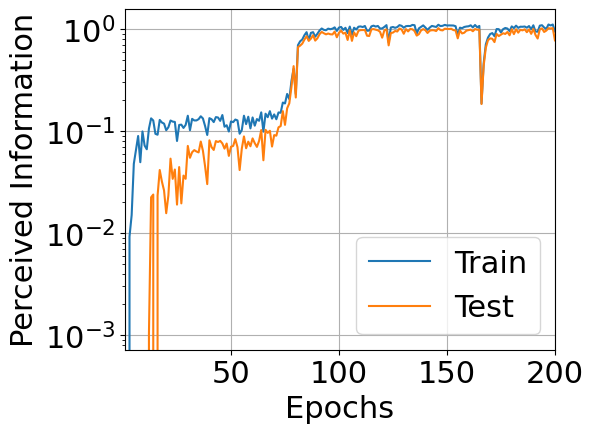

In [9]:
import gc
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
#print(len(pi_attack))
plt.plot(range(1, 201), pi_prof, label="Train")
plt.plot(range(1, 201), pi_attack, label="Test")

plt.yscale('log')
plt.xlabel("Epochs")
plt.ylabel("Perceived Information")
plt.xlim([1, 200])
plt.grid()
plt.legend()
plt.tight_layout()
#plt.savefig("PI_ches.png", dpi=200)
plt.show()


## Logit Visualization

 40/938 [>.............................] - ETA: 2s

2025-05-13 14:23:20.133695: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


152/152 [==============================] - 0s 1ms/step


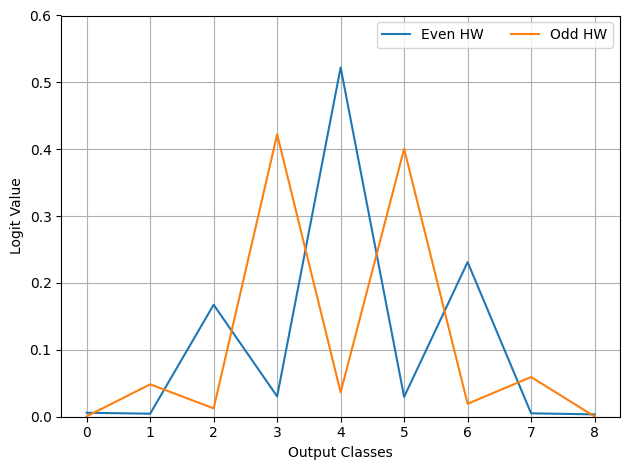

1/1 [==============================] - 0s 12ms/step


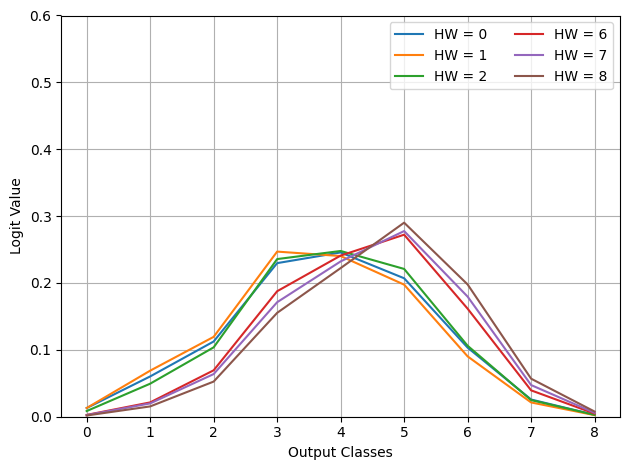

In [5]:
reload_model(100)
out_logits = []
for i in [0, 1]:
    indices, = np.where(dataset.attack_labels%2 == i)
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=f"Even HW" if i == 0 else "Odd HW")
plt.ylim([0, 0.6])
plt.grid()
plt.legend(ncol=2, loc=1)
plt.xlabel("Output Classes")
plt.ylabel("Logit Value")
plt.tight_layout()
plt.show()
gc.collect()
reload_model(50)
out_logits = []
for i in [0,1,2, 6, 7,8]:
    indices, = np.where(dataset.attack_labels == i)
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=f"HW = {i}")
plt.ylim([0, 0.6])
plt.grid()
plt.legend(ncol=2, loc=1)
plt.xlabel("Output Classes")
plt.ylabel("Logit Value")
plt.tight_layout()
plt.show()

## PCA stuff


313/313 [==============================] - 0s 1ms/step


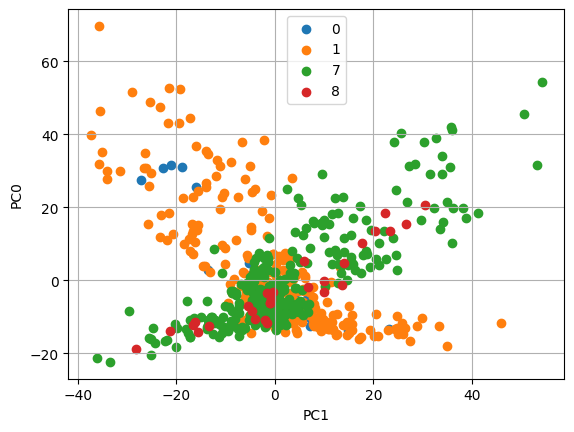

313/313 [==============================] - 0s 1ms/step


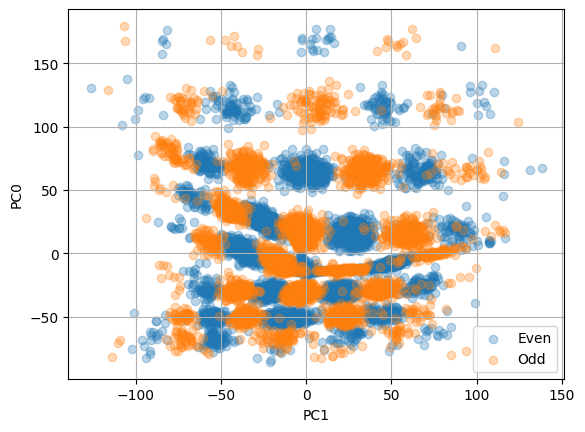

In [8]:
layer = 1
comp_n= 3
from sklearn.decomposition import PCA
gc.collect()
reload_model(50)
new_pca = PCA(n_components=comp_n)

#new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.fit_transform(tmp_att[layer])
in1 = 1
in2 = 0
for i in [0,1,7,8]:
    indices = np.where(dataset.attack_labels == i)
    plt.scatter(new_s1_att[indices,in1], new_s1_att[indices,in2], label=i)
plt.legend()
plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.grid()
plt.show()


comp_n=3
reload_model(100)
new_pca = PCA(n_components=comp_n)
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.fit_transform(tmp_att[layer])
in1 = 1
in2 = 0
for i in [0,1]:
    indices = np.where(dataset.attack_labels%2 == i)
    plt.scatter(new_s1_att[indices,in1], new_s1_att[indices,in2], label="Even" if i == 0 else "Odd", alpha=0.3)
plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.legend()
plt.grid()
plt.show()

### Code for plot paper

In [ ]:
reload_model(50)
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^
                dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))
font = {'size'   : 18}
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
#matplotlib.rc('font', **font)
# Prepare logits
out_logits = []
plt.figure(figsize=(20, 10))  # Adjust the figure size for 1x3 layout

# Subplot 1: Logits
plt.subplot(2, 3, 1)
for i in [0, 1, 2, 6, 7, 8]:
    indices, = np.where(dataset.attack_labels == i)
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=f"HW = {i}")
plt.ylim([0, 0.6])
plt.grid()
plt.legend(loc=0,ncol=2)
#plt.title("Logits by HW")
plt.xlabel("Output Classes")
plt.ylabel("Logit Value")
# PCA preparation
comp_n = 3
new_pca = PCA(n_components=comp_n)
layer = 1
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])

# Subplot 2: PC scatter plot for PC2 vs PC1
plt.subplot(2, 3, 3)
in1, in2 = 2, 1
for i in range(0, 2):
    on = np.where(dataset.attack_labels % 2 == i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
                label="Even HW" if i == 0 else "Odd HW", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()
plt.legend(loc=4)


# Subplot 3: PC scatter plot for PC1 vs PC0
plt.subplot(2, 3, 2)
for i in [0, 1, 2, 6, 7, 8]:
    on, = np.where(dataset.attack_labels == i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
                label=f"HW = {i}", alpha=0.5)
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.title("Epoch 50")
plt.grid()
plt.legend(loc=4)
#plt.title("PCA Scatter (PC1 vs PC0)")
reload_model(100)
plt.subplot(2, 3, 4)
for i in [0, 1]:
    indices, = np.where(dataset.attack_labels%2 == i)
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=f"Even HW" if i == 0 else "Odd HW")
plt.ylim([0, 0.6])
plt.grid()
plt.legend(loc=1)
plt.xlabel("Output Classes")
plt.ylabel("Logit Value")

# PCA preparation
comp_n = 3
new_pca = PCA(n_components=comp_n)
layer = 1
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])


# Subplot 2: PC scatter plot for PC2 vs PC1
plt.subplot(2, 3, 6)
in1, in2 = 2, 1
for i in range(0, 2):
    on = np.where(dataset.attack_labels % 2 == i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
                label="Even HW" if i == 0 else "Odd HW", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()

#plt.legend(loc=4)

# Subplot 3: PC scatter plot for PC1 vs PC0
plt.subplot(2, 3, 5)
for i in [0, 1, 2, 6, 7, 8]:
    on, = np.where(dataset.attack_labels == i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
                label=f"HW = {i}", alpha=0.5)
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.grid()
plt.title("Epoch 100")
#plt.legend(loc=4)

# Save or show the combined plot
plt.tight_layout()
#plt.savefig(f"combined_plots_ches_lowes.png", dpi=20)
 
plt.show()

938/938 [==============================] - 2s 2ms/step


KeyboardInterrupt: 

## Activation Patching

In [ ]:
reload_model(100)
comp_n = 3
new_pca = PCA(n_components=comp_n)
layer = 1
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
new_model_for_probe = Model(model.layers[layer+1].input, model.output)
copy_for_patch = new_s1_att.copy()
copy_for_patch[:, 1] = 140
copy_for_patch[:, 0] = -20


predicts = new_model_for_probe.predict(new_pca.inverse_transform(copy_for_patch))
low_hw_s1 = np.sum(predicts[:, 0:4], axis=1)
high_hw_s1 = np.sum(predicts[:, 5:9], axis=1)

copy_for_patch = new_s1_att.copy()

copy_for_patch[:, 2] = -130
copy_for_patch[:, 0] = -20


predicts = new_model_for_probe.predict(new_pca.inverse_transform(copy_for_patch))

low_hw_s2 = np.sum(predicts[:, 0:4], axis=1)
high_hw_s2= np.sum(predicts[:, 5:9], axis=1)

diff_s1 = high_hw_s1 - low_hw_s1
diff_s2 = high_hw_s2- low_hw_s2

final_hw_values_s1 = np.zeros(len(dataset.x_attack))
final_hw_values_s2 = np.zeros(len(dataset.x_attack))

argsort_s1 = np.argsort(diff_s1).astype(int)
argsort_s2 = np.argsort(diff_s2).astype(int)
hw_prior = np.zeros(9)
for i in range(256):
    hw_prior[hw(i)] += 1
hw_prior/=256
start_index = 0
for i in range(9):
    num_vals = int(len(dataset.x_attack)//(1/hw_prior[i]))
    if i == 4:
        num_vals +=4
    print(num_vals)
    final_hw_values_s1[argsort_s1[start_index:start_index+num_vals]] = i
    final_hw_values_s2[argsort_s2[start_index:start_index+num_vals]] = i
    start_index += num_vals
print(start_index)

313/313 [==============================] - 0s 892us/step
39
312
1093
2187
2738
2187
1093
312
39
10000


0 39
1 312
2 1093
3 2187
4 2738
5 2187
6 1093
7 312
8 39
0 39
1 312
2 1093
3 2187
4 2738
5 2187
6 1093
7 312
8 39


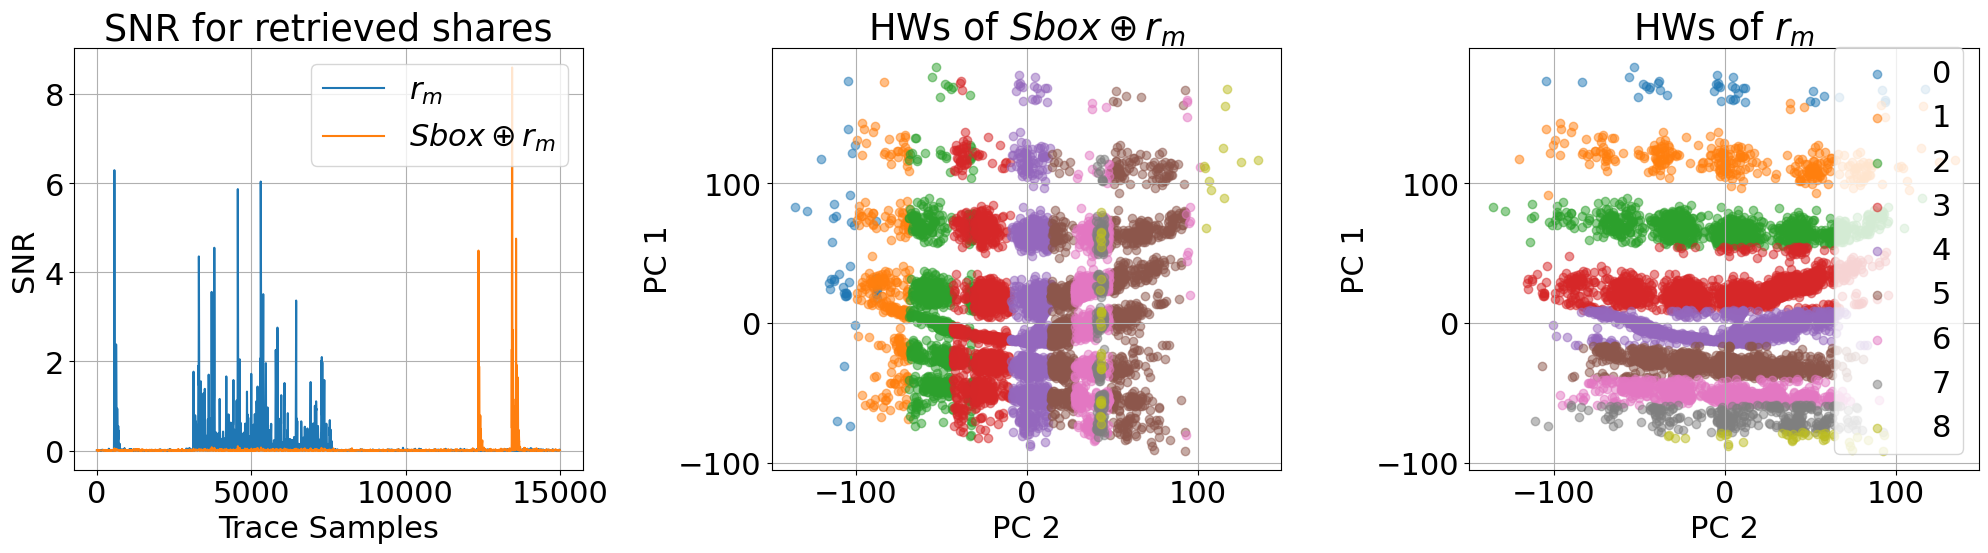

In [ ]:
plt.figure(figsize=(20, 6))  # Adjust the figure size for 1x3 layout

# Subplot 1: Logits
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
plt.subplot(1, 3, 3)
in1 = 2
in2 = 1
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
#plt.scatter(new_s1_att[:, in1], new_s1_att[:, in2], label="all", alpha=0.1)
for i in range(0, 9):
#     if i %2 == 0:
#           continue
     on = np.where(final_hw_values_s2==i)[0]
     print(i, len(on))
     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"{i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
# for i in range(6, 9):
# #     if i %2 == 0:
# #           continue
#      on = np.where(hw_values_s1==i)
#      plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"HW = {i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
plt.title("HWs of $r_m$")
plt.grid()

plt.legend(loc=4)

in1 = 2
in2 = 1
plt.subplot(1,3,2)
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.title("HWs of $Sbox \oplus r_m$")
#plt.scatter(new_s1_att[:, in1], new_s1_att[:, in2], label="all", alpha=0.1)
for i in range(0, 9):
#     if i %2 == 0:
#           continue
     on = np.where(final_hw_values_s1==i)[0]
     print(i, len(on))
     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"{i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
# for i in range(6, 9):
# #     if i %2 == 0:
# #           continue
#      on = np.where(hw_values_s1==i)
#      plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"HW = {i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
plt.grid()
#plt.legend()

plt.subplot(1,3,1)
plt.plot(snr_fast(dataset.x_attack, final_hw_values_s2), label="$r_m$")
plt.plot(snr_fast(dataset.x_attack, final_hw_values_s1), label="$Sbox \oplus r_m$")
plt.title("SNR for retrieved shares")
plt.xlabel("Trace Samples")
plt.legend(loc=1)
plt.grid()
plt.tight_layout()
plt.ylabel("SNR")
# plt.savefig("Combined_patch_ches_lowest_res.png", dpi=20)
# plt.savefig("Combined_patch_ches_lower_res.png", dpi=100)
# plt.savefig("Combined_patch_ches.png", dpi=200)
plt.show()